# Econ 390 - Extra Credit Answers
## by M McMain
This Extra Credit will cover the Lasso. Be sure to import any packages your code needs to run and make sure the code runs without any errors.

1. Go to [this](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand) link and download the Seoul Bike Sharing Demand dataset and import the dataset.
   - *Hint: There is something in the variable names that causes an error when importing. Delete the character(s) that are a problem*
   - Keep only the rows where the bikes are functional.
   - Then drop `Functioning Day`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

seed = 42

In [2]:
bikes = pd.read_csv("C:\\Users\\Micha\\Downloads\\SeoulBikeData.csv")
bikes = bikes[bikes["Functioning Day"]=="Yes"]
bikes = bikes.drop("Functioning Day", axis=1)
bikes

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday


2. The outcome variable of interest is `Rented Bike Count`, as we want to know which variables have the largest effect on how many bikes are rented. We need to do some data cleaning to get the variables into the correct form.
   - Keep only `Rented Bike Count`, `Wind speed (m/s)`, `Seasons`, `Humidity(%)`, `Visibility (10m)`, and `Holiday`
   - Use [pandas.get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) to convert `Seasons` into dummy variables, since the lasso command doesn't work with categorical variables. Then delete `Seasons` so they aren't included in the analysis.
   - `get_dummies` returns a DataFrame, so use `df.join(pd.get_dummies(df[.]))` to append the results to your original DataFrame
   - Choose one season to be the "comparison season" and drop that variable
   - Convert `Holiday` into 1 if it is a Holiday and 0 otherwise
   - Convert `Visibility (10m)` and `Rented Bike Count` to log since the values are so big (upwards of 2000)

In [3]:
bikes = bikes[["Rented Bike Count", "Wind speed (m/s)", "Seasons", "Humidity(%)","Visibility (10m)", "Holiday"]]
bikes = bikes.join(pd.get_dummies(bikes["Seasons"]))
bikes = bikes.drop(["Seasons","Autumn"],axis=1)
bikes["Holiday"] = bikes["Holiday"]=="Holiday"
bikes["Visibility (10m)"] = np.log(bikes["Visibility (10m)"])
bikes["Rented Bike Count"] = np.log(bikes["Rented Bike Count"])
bikes

,Rented Bike Count,Wind speed (m/s),Humidity(%),Visibility (10m),Holiday,Spring,Summer,Winter
0,5.537334,2.2,37,7.600902,False,False,False,True
1,5.318120,0.8,38,7.600902,False,False,False,True
2,5.153292,1.0,39,7.600902,False,False,False,True
3,4.672829,0.9,40,7.600902,False,False,False,True
4,4.356709,2.3,36,7.600902,False,False,False,True
...,...,...,...,...,...,...,...,...
8755,6.910751,2.6,34,7.546446,False,False,False,False
8756,6.638568,2.3,37,7.600902,False,False,False,False
8757,6.542472,0.3,39,7.584773,False,False,False,False
8758,6.568078,1.0,41,7.527794,False,False,False,False


3. Create a training and testing dataset using `seed` as the `random_state` with `test_size=0.2`.

In [4]:
train_bikes, test_bikes = train_test_split(bikes, random_state=seed, test_size=0.2)
train_bikes.head()

,Rented Bike Count,Wind speed (m/s),Humidity(%),Visibility (10m),Holiday,Spring,Summer,Winter
8691,5.117994,1.6,38,6.810142,False,False,False,False
6042,7.522941,2.3,86,7.126087,False,False,True,False
4788,6.895683,2.2,45,6.475433,False,False,True,False
6574,7.489412,0.9,80,7.524021,False,False,True,False
3716,7.236339,3.4,46,7.570443,False,True,False,False


4. Run Lasso on the training dataset with `Rented Bike` on the left and all other variables except `Date` on the right for a grid of $\alpha$ between 0 and 1 of size 100. Set `random_state=seed`.
   - *Hint: Which column is the "y" variable? Which columns are the "x" variables?*
   - Note you don't want to actually include zero as that is just OLS

In [5]:
# Collect the results for many different alpha
mse_all = []
alpha_all = []
coef_all = []
max_range = 100
for i in range(1,max_range,1):
    reg_lasso = Lasso(alpha=i/max_range, random_state=seed)
    reg_lasso.fit(train_bikes.iloc[:, 1:], train_bikes.iloc[:,0])
    coef = reg_lasso.coef_
    coef_all.append(coef)
    alpha_all = alpha_all + [i/max_range]

5. Plot and label the coefficients for different values of $\alpha$

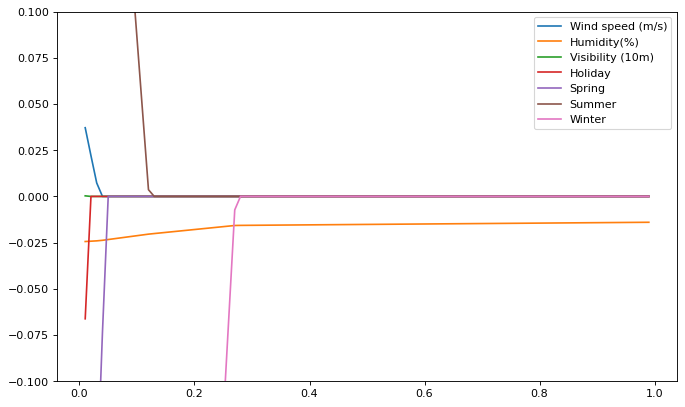

In [6]:
# Plot the coefficients for different values of alpha, natural Feature Selection
plt.figure(figsize=(10, 6), dpi=80);
#Set ylim to get a closer look around 0
plt.ylim(-0.1,0.1)
plt.plot(alpha_all, coef_all, label=test_bikes.columns[1:])
plt.legend();

6. Which features seem to be the most important? Which are the least?
   - Reflect on how you would present this information and what you would conclude to the bike sharing company
   - Reflect on what other features you think could impact how many bikes are rented, whether they are in the data or not

**Most Important**: Humidity and Winter (relative to Autumn)

**Least Important**: Visibility, Holiday, and Wind Speed